<a href="https://colab.research.google.com/github/nivethajayakaleeswaran-wq/house-price-prediction/blob/main/house_price_prediction_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
train=pd.read_csv("/content/train.csv")
test=pd.read_csv("/content/test.csv")

In [ ]:
df=pd.read_csv("/content/train.csv")
df=pd.read_csv("/content/test.csv")

In [ ]:
print(df.head())

     Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0  1461          20       RH         80.0    11622   Pave   NaN      Reg   
1  1462          20       RL         81.0    14267   Pave   NaN      IR1   
2  1463          60       RL         74.0    13830   Pave   NaN      IR1   
3  1464          60       RL         78.0     9978   Pave   NaN      IR1   
4  1465         120       RL         43.0     5005   Pave   NaN      IR1   

  LandContour Utilities  ... ScreenPorch PoolArea PoolQC  Fence MiscFeature  \
0         Lvl    AllPub  ...         120        0    NaN  MnPrv         NaN   
1         Lvl    AllPub  ...           0        0    NaN    NaN        Gar2   
2         Lvl    AllPub  ...           0        0    NaN  MnPrv         NaN   
3         Lvl    AllPub  ...           0        0    NaN    NaN         NaN   
4         HLS    AllPub  ...         144        0    NaN    NaN         NaN   

  MiscVal MoSold  YrSold  SaleType  SaleCondition  
0       0      6

In [ ]:
print(df.tail())

        Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
1454  2915         160       RM         21.0     1936   Pave   NaN      Reg   
1455  2916         160       RM         21.0     1894   Pave   NaN      Reg   
1456  2917          20       RL        160.0    20000   Pave   NaN      Reg   
1457  2918          85       RL         62.0    10441   Pave   NaN      Reg   
1458  2919          60       RL         74.0     9627   Pave   NaN      Reg   

     LandContour Utilities  ... ScreenPorch PoolArea PoolQC  Fence  \
1454         Lvl    AllPub  ...           0        0    NaN    NaN   
1455         Lvl    AllPub  ...           0        0    NaN    NaN   
1456         Lvl    AllPub  ...           0        0    NaN    NaN   
1457         Lvl    AllPub  ...           0        0    NaN  MnPrv   
1458         Lvl    AllPub  ...           0        0    NaN    NaN   

     MiscFeature MiscVal MoSold  YrSold  SaleType  SaleCondition  
1454         NaN       0      6    20

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

In [ ]:
df.shape

(1459, 80)

In [ ]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,4
LotFrontage,227
LotArea,0
...,...
MiscVal,0
MoSold,0
YrSold,0
SaleType,1


In [ ]:
df.nunique()

,0
Id,1459
MSSubClass,16
MSZoning,5
LotFrontage,115
LotArea,1106
...,...
MiscVal,26
MoSold,12
YrSold,5
SaleType,9


In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [ ]:
target_col = train.columns[-1]
X = train.drop(columns=[target_col])
y = train[target_col]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
cat_cols = X.select_dtypes(include=['object', 'category']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))  ])
cat_transformer = Pipeline(steps=[ ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')) ])
preprocessor = ColumnTransformer(
    transformers=[ ('num', num_transformer, num_cols),
                   ('cat', cat_transformer, cat_cols)
                   ])

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
df = pd.read_csv("/content/test.csv")
df = pd.read_csv("/content/train.csv")
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
df.to_csv("preprocessed_dataset.csv", index=False)

print(" File saved as preprocessed_dataset.csv")

 File saved as preprocessed_dataset.csv


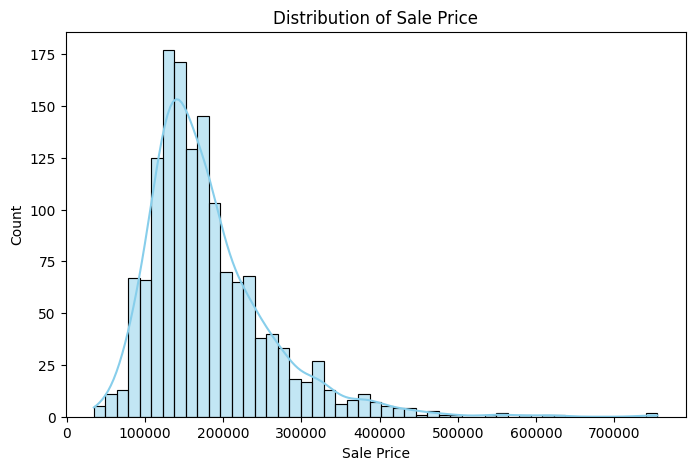

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df["SalePrice"], kde=True, color="skyblue")
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.show()


Descriptive Statistics for GrLivArea and SalePrice:
         GrLivArea      SalePrice
count  1460.000000    1460.000000
mean   1515.463699  180921.195890
std     525.480383   79442.502883
min     334.000000   34900.000000
25%    1129.500000  129975.000000
50%    1464.000000  163000.000000
75%    1776.750000  214000.000000
max    5642.000000  755000.000000


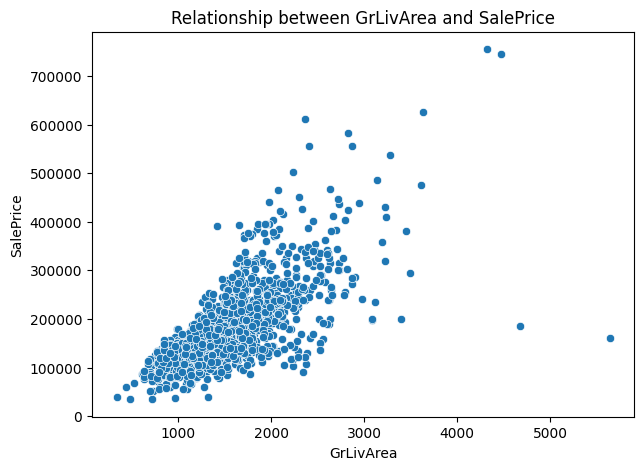


Correlation between GrLivArea and SalePrice: 0.71


In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/train.csv")

# Select any two columns for analysis
col1 = 'GrLivArea'
col2 = 'SalePrice'

# Display basic statistics
print(f"\nDescriptive Statistics for {col1} and {col2}:")
print(df[[col1, col2]].describe())

# Scatter Plot to visualize relationship
plt.figure(figsize=(7,5))
sns.scatterplot(x=df[col1], y=df[col2])
plt.title(f"Relationship between {col1} and {col2}")
plt.xlabel(col1)
plt.ylabel(col2)
plt.show()

# Correlation value
correlation = df[[col1, col2]].corr().iloc[0, 1]
print(f"\nCorrelation between {col1} and {col2}: {correlation:.2f}")


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [ ]:
X=df[['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
                     '1stFlrSF', 'FullBath', 'YearBuilt', 'TotRmsAbvGrd',
                     'Fireplaces', 'LotArea']]
y=df["SalePrice"]

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object', 'category']).columns
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
lin_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
     ('regressor', LinearRegression())
])
lin_model.fit(X_train, y_train)
lin_preds = lin_model.predict(X_val)

In [ ]:
rf_model = Pipeline(steps=[
     ('preprocessor', preprocessor),
     ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
     ])
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)

In [ ]:
def print_metrics(name, y_true, y_pred):
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)
  print(f"\n{name} Performance:")
  print(f"MSE: {mse:.4f}")
  print(f"RMSE: {rmse:.4f}")
  print(f"MAE: {mae:.4f}")
  print(f"R²: {r2:.4f}")

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def print_metrics(y_true, y_pred):
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)
  return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}
results = {
    "Linear Regression": print_metrics(y_val, lin_preds),
    "Random Forest": print_metrics(y_val, rf_preds) }

In [ ]:
print_metrics("Linear Regression", y_val, lin_preds)
print_metrics("Random Forest", y_val, rf_preds)


Linear Regression Performance:
MSE: 1554147852.6350
RMSE: 39422.6820
MAE: 24708.4968
R²: 0.7974

Random Forest Performance:
MSE: 780972838.8274
RMSE: 27945.8913
MAE: 18126.1527
R²: 0.8982


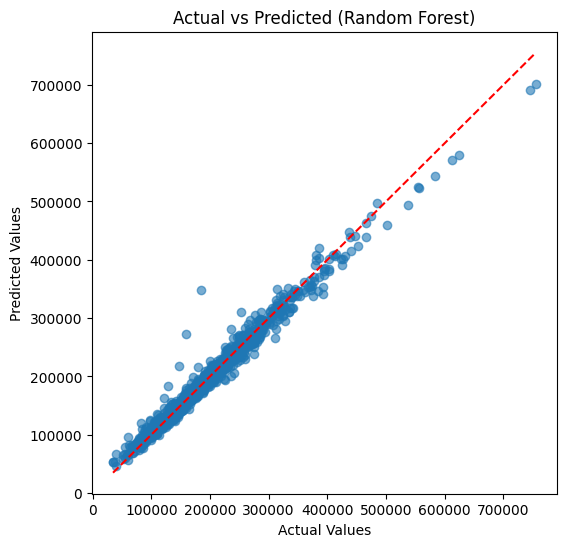

In [ ]:
results = {
    "Random Forest": get_metrics(y_val, rf_preds) }

rf_model.fit(X, y)
y_pred = rf_model.predict(X)

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # ideal line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [ ]:
test_preds = rf_model.predict(test)
submission = pd.DataFrame({ "Id": test.index,
                           "Prediction": test_preds })
submission.to_csv("submission.csv", index=False)
print("\nPredictions saved to submission.csv")


Predictions saved to submission.csv


In [ ]:
import pandas as pd
import numpy as np
important_columns = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF',
                     '1stFlrSF', 'FullBath', 'YearBuilt', 'TotRmsAbvGrd',
                     'Fireplaces', 'LotArea']
input_data = {}
for col in important_columns:
    value = input(f"Enter {col}: ")
    try:
        value = float(value)
    except:
        pass
    input_data[col] = [value]
input_df = pd.DataFrame(input_data)
predicted_value=model.predict(input_df)
print("\n predicted output:",predicted_value[0])


Enter OverallQual: 7
Enter GrLivArea: 1710
Enter GarageCars: 1
Enter TotalBsmtSF: 865
Enter 1stFlrSF: 865
Enter FullBath: 1
Enter YearBuilt: 2002
Enter TotRmsAbvGrd: 8
Enter Fireplaces: 1
Enter LotArea: 8500

 predicted output: 208891.8515996779


In [ ]:
model_columns = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', '1stFlrSF',
                 'FullBath', 'YearBuilt', 'TotRmsAbvGrd', 'Fireplaces', 'LotArea', ...]
model_medians = {col: value}
model_modes = {col: value}